Shape: (100000, 28)

Dtypes:
 Conflict_Name                                  str
Conflict_Type                                  str
Region                                         str
Start_Year                                   int64
End_Year                                     int64
Status                                         str
Primary_Country                                str
Pre_War_Unemployment_%                     float64
During_War_Unemployment_%                  float64
Unemployment_Spike_Percentage_Points       float64
Most_Affected_Sector                           str
Youth_Unemployment_Change_%                float64
Pre_War_Poverty_Rate_%                     float64
During_War_Poverty_Rate_%                  float64
Extreme_Poverty_Rate_%                     float64
Food_Insecurity_Rate_%                     float64
Households_Fallen_Into_Poverty_Estimate      int64
GDP_Change_%                               float64
Inflation_Rate_%                           float64
C

C:\Users\kefya\AppData\Local\Temp\ipykernel_7908\2658451476.py:48: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include="object").columns
C:\Users\kefya\AppData\Local\Temp\ipykernel_7908\2658451476.py:91: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/m


Missing after imputation:
 conflict_name                                   0
conflict_type                                   0
region                                          0
start_year                                      0
end_year                                        0
status                                          0
primary_country                                 0
pre_war_unemployment_                           0
during_war_unemployment_                        0
unemployment_spike_percentage_points            0
most_affected_sector                            0
youth_unemployment_change_                      0
pre_war_poverty_rate_                           0
during_war_poverty_rate_                        0
extreme_poverty_rate_                           0
food_insecurity_rate_                           0
households_fallen_into_poverty_estimate         0
gdp_change_                                     0
inflation_rate_                                 0
currency_devaluation_ 

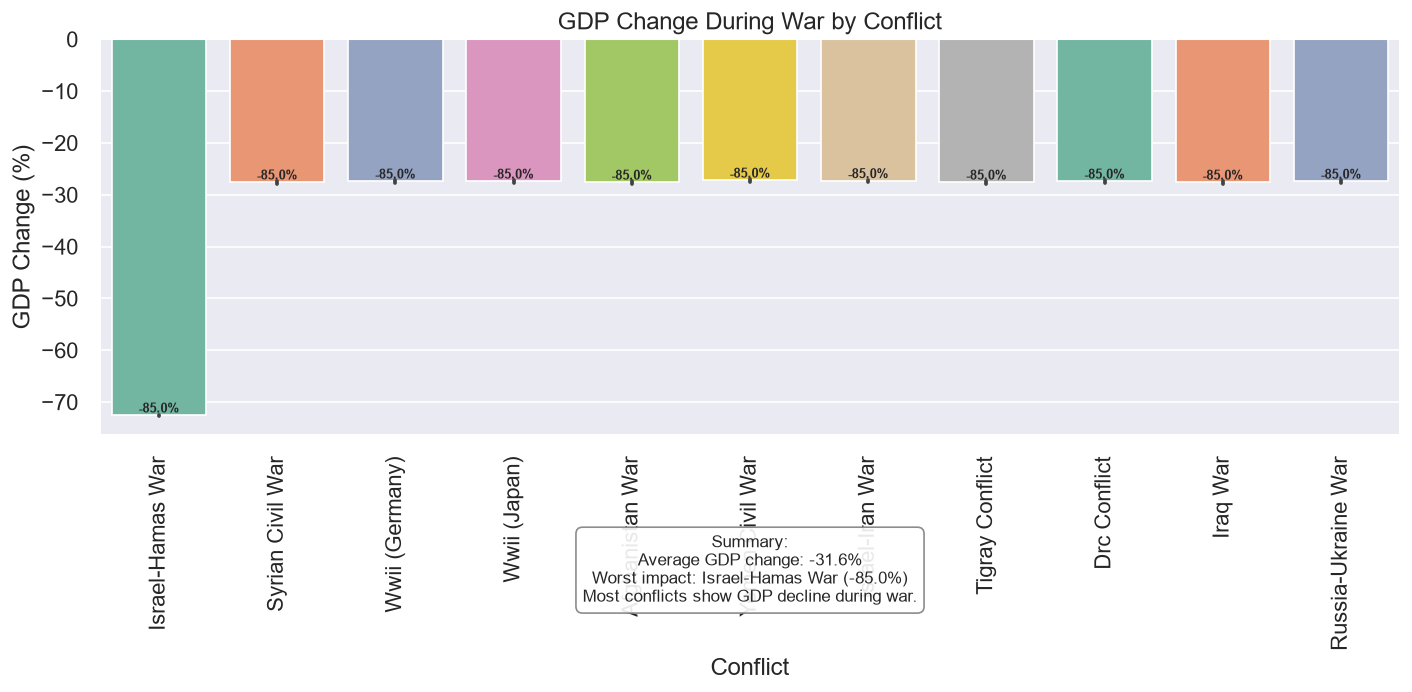


KPI 1 – Worst GDP change conflict:
 conflict_name    Israel-Hamas War
gdp_change_                 -85.0
Name: 37726, dtype: object


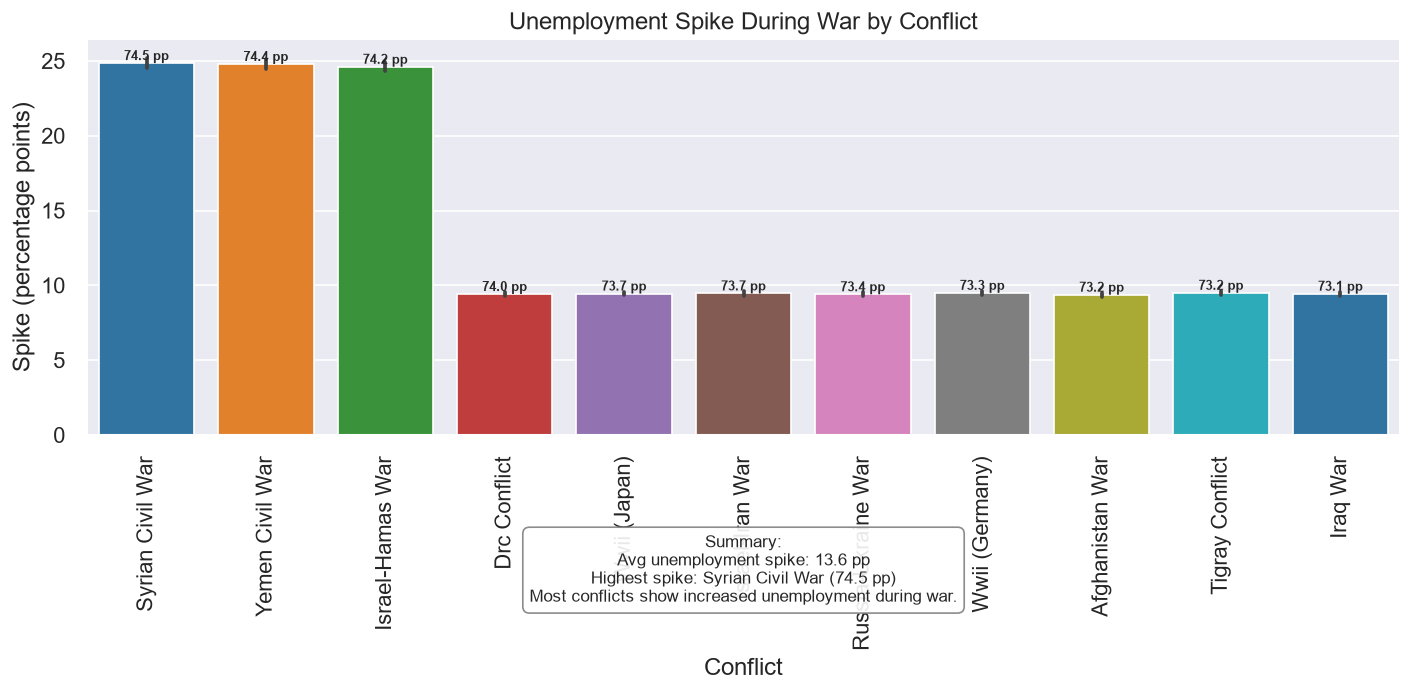


KPI 2 – Max unemployment spike (pp): 74.47


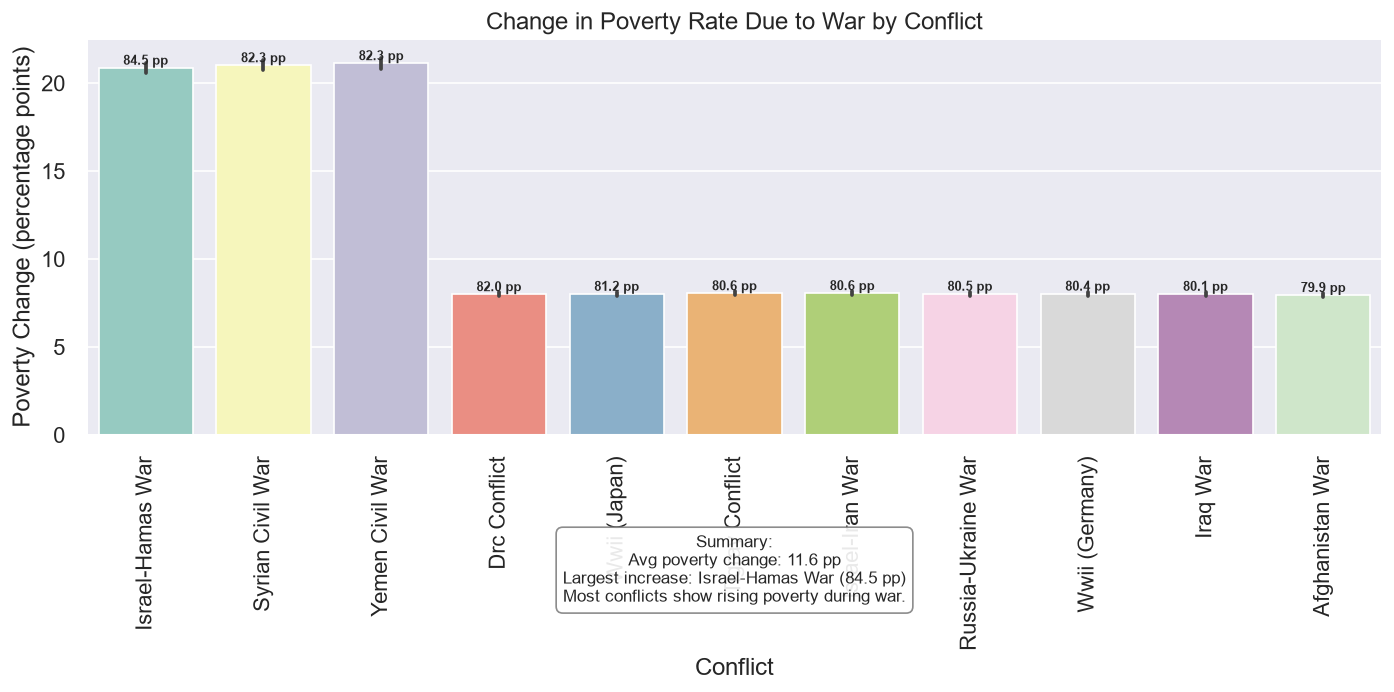


KPI 3 – Average poverty rate change (pp): 11.5583653


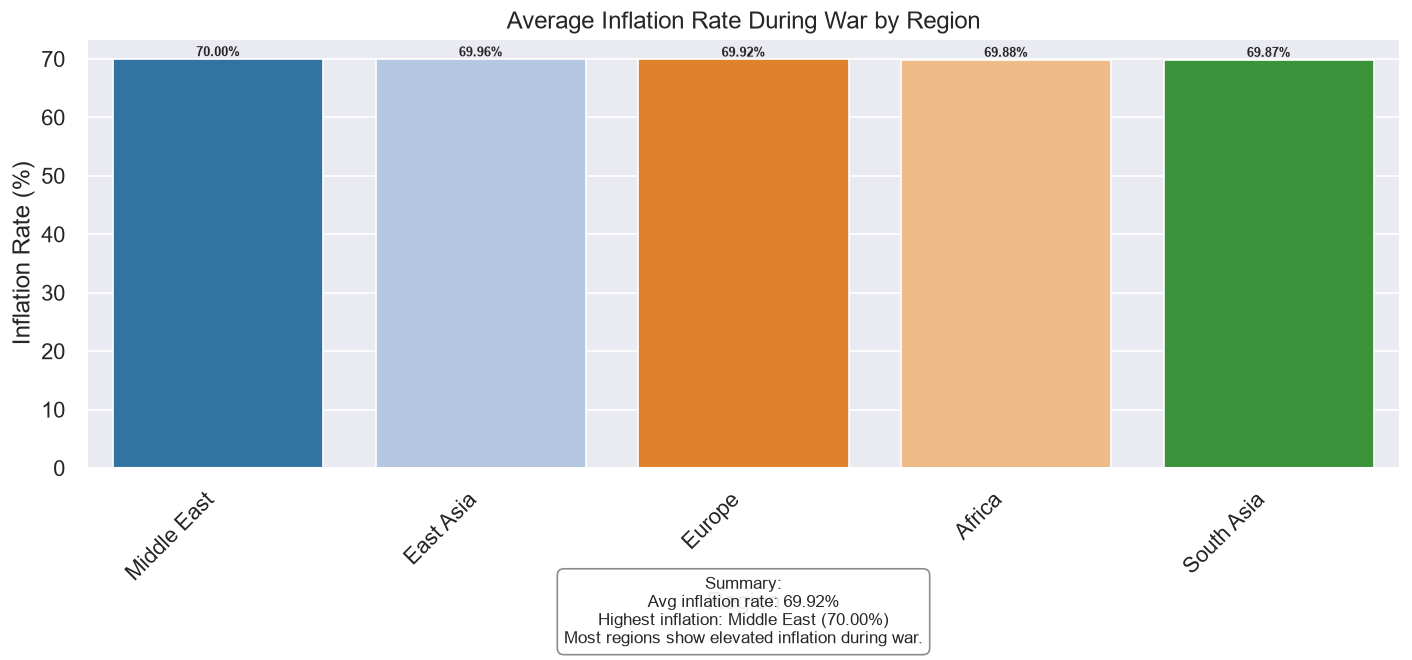


KPI 4 – Region with highest inflation:
 region             Middle East
inflation_rate_      69.995181
Name: 3, dtype: object


C:\Users\kefya\AppData\Local\Temp\ipykernel_7908\2658451476.py:419: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\kefya\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:158: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


In [ ]:
# =========================
# WAR IMPACT ON ECONOMY — FULL CLEANED SCRIPT
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set(font_scale=1.2)
plt.rcParams["figure.figsize"] = (10, 6)

# =========================
# 1. Load data
# =========================
df = pd.read_csv("war_economic_impact_dataset.csv")

# =========================
# 2. Inspect data
# =========================
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nHead:\n", df.head())
print("\nSample:\n", df.sample(5, random_state=42))
print("\nInfo:")
df.info()
print("\nDescribe (numeric):")
print(df.describe())
print("\nDescribe (all):")
print(df.describe(include="all"))
print("\nMissing per column:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

# =========================
# 3–4. Clean, strip, standardize, replace NaN numeric with median
# =========================

# Clean column names
df.columns = (
    df.columns.str.strip()
              .str.lower()
              .str.replace(" ", "_")
              .str.replace(r"[^0-9a-zA-Z_]", "", regex=True)
)

# Strip string columns
str_cols = df.select_dtypes(include="object").columns
for col in str_cols:
    df[col] = df[col].astype(str).str.strip()

# Standardize text fields
for col in ["conflict_name", "conflict_type", "region", "status", "most_affected_sector", "primary_country"]:
    if col in df.columns:
        df[col] = df[col].str.title()

# Convert numeric candidates
num_candidates = [
    "pre_war_unemployment_",
    "during_war_unemployment_",
    "unemployment_spike_percentage_points",
    "youth_unemployment_change_",
    "pre_war_poverty_rate_",
    "during_war_poverty_rate_",
    "extreme_poverty_rate_",
    "food_insecurity_rate_",
    "households_fallen_into_poverty_estimate",
    "gdp_change_",
    "inflation_rate_",
    "currency_devaluation_",
    "cost_of_war_usd",
    "estimated_reconstruction_cost_usd",
    "informal_economy_size_pre_war_",
    "informal_economy_size_during_war_",
    "currency_black_market_rate_gap_",
    "black_market_activity_level"
]
for col in num_candidates:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Imputation (clean copy)
df_clean = df.copy()

# Numeric → median
num_cols = df_clean.select_dtypes(include=["float64","int64","Int64"]).columns
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Categorical → mode / Unknown
cat_cols = df_clean.select_dtypes(include="object").columns
for col in cat_cols:
    mode = df_clean[col].mode()
    df_clean[col] = df_clean[col].fillna(mode.iloc[0] if not mode.empty else "Unknown")

print("\nMissing after imputation:\n", df_clean.isna().sum())

# =========================
# 5. Handle missing values & date parse
# =========================
for col in ["start_year", "end_year"]:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce").astype("Int64")

# =========================
# PLOT 1 — GDP CHANGE BY CONFLICT
# =========================

if {"conflict_name","gdp_change_"}.issubset(df_clean.columns):

    plot_data = df_clean.sort_values("gdp_change_")

    plt.figure(figsize=(12,6))
    ax = sns.barplot(
        data=plot_data,
        x="conflict_name",
        y="gdp_change_",
        hue="conflict_name",
        palette="Set2",
        legend=False
    )

    plt.xticks(rotation=90)
    plt.title("GDP Change During War by Conflict")
    plt.xlabel("Conflict")
    plt.ylabel("GDP Change (%)")

    for p, val in zip(ax.patches, plot_data["gdp_change_"]):
        ax.annotate(
            f"{val:.1f}%",
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold"
        )

    avg_change = plot_data["gdp_change_"].mean()
    worst_conflict = plot_data.loc[plot_data["gdp_change_"].idxmin(), "conflict_name"]
    worst_value = plot_data["gdp_change_"].min()

    summary_text = (
        f"Summary:\n"
        f"Average GDP change: {avg_change:.1f}%\n"
        f"Worst impact: {worst_conflict} ({worst_value:.1f}%)\n"
        f"Most conflicts show GDP decline during war."
    )

    ax.annotate(
        summary_text,
        xy=(0.5, -0.25),
        xycoords="axes fraction",
        ha="center",
        va="top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.9)
    )

    plt.tight_layout()
    plt.show()

    kpi1 = df_clean.loc[df_clean["gdp_change_"].idxmin(), ["conflict_name","gdp_change_"]]
    print("\nKPI 1 – Worst GDP change conflict:\n", kpi1)

# =========================
# PLOT 2 — UNEMPLOYMENT SPIKE
# =========================

required_cols = {"conflict_name","unemployment_spike_percentage_points"}
missing = required_cols - set(df_clean.columns)
if missing:
    raise ValueError(f"Missing columns: {missing}")

plot_data = df_clean.sort_values("unemployment_spike_percentage_points", ascending=False)

plt.figure(figsize=(12,6))
ax = sns.barplot(
    data=plot_data,
    x="conflict_name",
    y="unemployment_spike_percentage_points",
    hue="conflict_name",
    palette="tab10",
    legend=False
)

plt.xticks(rotation=90)
plt.title("Unemployment Spike During War by Conflict")
plt.xlabel("Conflict")
plt.ylabel("Spike (percentage points)")

for p, val in zip(ax.patches, plot_data["unemployment_spike_percentage_points"]):
    ax.annotate(
        f"{val:.1f} pp",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold"
    )

avg_spike = plot_data["unemployment_spike_percentage_points"].mean()
max_conflict = plot_data.loc[plot_data["unemployment_spike_percentage_points"].idxmax(), "conflict_name"]
max_value = plot_data["unemployment_spike_percentage_points"].max()

summary_text = (
    f"Summary:\n"
    f"Avg unemployment spike: {avg_spike:.1f} pp\n"
    f"Highest spike: {max_conflict} ({max_value:.1f} pp)\n"
    f"Most conflicts show increased unemployment during war."
)

ax.annotate(
    summary_text,
    xy=(0.5, -0.25),
    xycoords="axes fraction",
    ha="center",
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.9)
)

plt.tight_layout()
plt.show()

kpi2 = df_clean["unemployment_spike_percentage_points"].max()
print("\nKPI 2 – Max unemployment spike (pp):", kpi2)

# =========================
# PLOT 3 — POVERTY CHANGE
# =========================

if {"conflict_name","pre_war_poverty_rate_","during_war_poverty_rate_"}.issubset(df_clean.columns):

    df_clean["poverty_change_"] = df_clean["during_war_poverty_rate_"] - df_clean["pre_war_poverty_rate_"]
    plot_data = df_clean.sort_values("poverty_change_", ascending=False)

    plt.figure(figsize=(12,6))
    ax = sns.barplot(
        data=plot_data,
        x="conflict_name",
        y="poverty_change_",
        hue="conflict_name",
        palette="Set3",
        legend=False
    )

    plt.xticks(rotation=90)
    plt.title("Change in Poverty Rate Due to War by Conflict")
    plt.xlabel("Conflict")
    plt.ylabel("Poverty Change (percentage points)")

    for p, val in zip(ax.patches, plot_data["poverty_change_"]):
        ax.annotate(
            f"{val:.1f} pp",
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold"
        )

    avg_change = plot_data["poverty_change_"].mean()
    worst_conflict = plot_data.loc[plot_data["poverty_change_"].idxmax(), "conflict_name"]
    worst_value = plot_data["poverty_change_"].max()

    summary_text = (
        f"Summary:\n"
        f"Avg poverty change: {avg_change:.1f} pp\n"
        f"Largest increase: {worst_conflict} ({worst_value:.1f} pp)\n"
        f"Most conflicts show rising poverty during war."
    )

    ax.annotate(
        summary_text,
        xy=(0.5, -0.25),
        xycoords="axes fraction",
        ha="center",
        va="top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.9)
    )

    plt.tight_layout()
    plt.show()

    kpi3 = df_clean["poverty_change_"].mean()
    print("\nKPI 3 – Average poverty rate change (pp):", kpi3)

    # ---------- Plot 4: Inflation rate by region (bar + KPI) ----------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if {"region","inflation_rate_"}.issubset(df_clean.columns):

    # Compute average inflation per region
    infl_region = df_clean.groupby("region")["inflation_rate_"].mean().reset_index()

    # Sort for cleaner visualization
    infl_region = infl_region.sort_values("inflation_rate_", ascending=False)

    plt.figure(figsize=(12,6))
    ax = sns.barplot(
        data=infl_region,
        x="region",
        y="inflation_rate_",
        hue="region",
        palette="tab20",
        legend=False
    )

    plt.xticks(rotation=45, ha="right")
    plt.title("Average Inflation Rate During War by Region")
    plt.xlabel("Region")
    plt.ylabel("Inflation Rate (%)")

    # ---- Label each bar with increase/decrease ----
    for p, val in zip(ax.patches, infl_region["inflation_rate_"]):
        label = f"{val:.2f}%"
        ax.annotate(
            label,
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold"
        )

    # ---- Summary box (bottom center) ----
    avg_infl = infl_region["inflation_rate_"].mean()
    highest_region = infl_region.loc[infl_region["inflation_rate_"].idxmax(), "region"]
    highest_value = infl_region["inflation_rate_"].max()

    summary_text = (
        f"Summary:\n"
        f"Avg inflation rate: {avg_infl:.2f}%\n"
        f"Highest inflation: {highest_region} ({highest_value:.2f}%)\n"
        f"Most regions show elevated inflation during war."
    )

    ax.annotate(
        summary_text,
        xy=(0.5, -0.25),
        xycoords="axes fraction",
        ha="center",
        va="top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.9)
    )

    plt.tight_layout()
    plt.show()

    # ---- KPI 4 ----
    kpi4 = infl_region.loc[infl_region["inflation_rate_"].idxmax()]
    print("\nKPI 4 – Region with highest inflation:\n", kpi4)

# ---------- Plot 5: Cost of war vs reconstruction cost (scatter) ----------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if {"cost_of_war_usd","estimated_reconstruction_cost_usd","region"}.issubset(df_clean.columns):

    plt.figure(figsize=(12,6))
    ax = sns.scatterplot(
        data=df_clean,
        x="cost_of_war_usd",
        y="estimated_reconstruction_cost_usd",
        hue="region",
        palette="tab10",
        alpha=0.8
    )

    plt.title("Cost of War vs Estimated Reconstruction Cost")
    plt.xlabel("Cost of War (USD)")
    plt.ylabel("Reconstruction Cost (USD)")

    # ---- Label each point with % increase/decrease ----
    df_clean["pct_change"] = (
        (df_clean["estimated_reconstruction_cost_usd"] - df_clean["cost_of_war_usd"])
        / df_clean["cost_of_war_usd"]
    ) * 100

    for i, row in df_clean.iterrows():
        ax.annotate(
            f"{row['pct_change']:.1f}%",
            (row["cost_of_war_usd"], row["estimated_reconstruction_cost_usd"]),
            textcoords="offset points",
            xytext=(5,5),
            fontsize=8,
            fontweight="bold"
        )

    # ---- Summary box (top center) ----
    avg_pct_change = df_clean["pct_change"].mean()
    max_region = df_clean.loc[df_clean["pct_change"].idxmax(), "region"]
    max_value = df_clean["pct_change"].max()

    summary_text = (
        f"Summary:\n"
        f"Avg % change: {avg_pct_change:.1f}%\n"
        f"Largest increase: {max_region} ({max_value:.1f}%)\n"
        f"Reconstruction costs generally exceed war costs."
    )

    ax.annotate(
        summary_text,
        xy=(0.5, 1.05),
        xycoords="axes fraction",
        ha="center",
        va="bottom",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.9)
    )

    plt.tight_layout()
    plt.show()

    # ---- KPI 5 ----
    kpi5 = df_clean["cost_of_war_usd"].corr(df_clean["estimated_reconstruction_cost_usd"])
    print("\nKPI 5 – Corr(cost_of_war_usd, estimated_reconstruction_cost_usd):", kpi5)

# ---------- Plot 6: Informal economy pre vs during (by region, bar) ----------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if {"region","informal_economy_size_pre_war_","informal_economy_size_during_war_"}.issubset(df_clean.columns):

    # Compute regional averages
    inf_region = df_clean.groupby("region")[[
        "informal_economy_size_pre_war_",
        "informal_economy_size_during_war_"
    ]].mean().reset_index()

    # Compute % increase/decrease
    inf_region["pct_change"] = (
        (inf_region["informal_economy_size_during_war_"] -
         inf_region["informal_economy_size_pre_war_"])
        / inf_region["informal_economy_size_pre_war_"]
    ) * 100

    # Plot
    plt.figure(figsize=(12,6))
    ax = inf_region.set_index("region")[[
        "informal_economy_size_pre_war_",
        "informal_economy_size_during_war_"
    ]].plot(
        kind="bar",
        color=["tab:green","tab:orange"]
    )

    plt.title("Informal Economy Size Pre- vs During War by Region")
    plt.xlabel("Region")
    plt.ylabel("Size (%) or index)")
    plt.xticks(rotation=45, ha="right")
    plt.legend(["Pre-war","During war"])

    # ---- Label each bar with % change ----
    for idx, row in inf_region.iterrows():
        ax.annotate(
            f"{row['pct_change']:.1f}%",
            (idx, row["informal_economy_size_during_war_"]),
            textcoords="offset points",
            xytext=(5,5),
            fontsize=8,
            fontweight="bold"
        )

    # ---- Summary box (top-left) ----
    avg_change = inf_region["pct_change"].mean()
    max_region = inf_region.loc[inf_region["pct_change"].idxmax(), "region"]
    max_value = inf_region["pct_change"].max()

    summary_text = (
        f"Summary:\n"
        f"Avg % change: {avg_change:.1f}%\n"
        f"Largest increase: {max_region} ({max_value:.1f}%)\n"
        f"Informal economy generally expands during war."
    )

    ax.annotate(
        summary_text,
        xy=(0.02, 1.02),
        xycoords="axes fraction",
        ha="left",
        va="bottom",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.9)
    )

    plt.tight_layout()
    plt.show()

    # ---- KPI 6 ----
    kpi6 = inf_region["pct_change"].mean()
    print("\nKPI 6 – Average informal economy increase:", kpi6)

# ---------- Plot 7: Correlation heatmap ----------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

corr_cols = [
    "gdp_change_",
    "unemployment_spike_percentage_points",
    "poverty_change_" if "poverty_change_" in df_clean.columns else None,
    "inflation_rate_",
    "currency_devaluation_",
    "food_insecurity_rate_",
    "black_market_activity_level"
]
corr_cols = [c for c in corr_cols if c is not None and c in df_clean.columns]

if len(corr_cols) >= 2:

    corr_matrix = df_clean[corr_cols].corr()

    plt.figure(figsize=(10,8))
    ax = sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
    plt.title("Correlation Heatmap – Economic & Social War Impacts")
    plt.tight_layout()

    # ---- Compute mean values for summary ----
    pct_changes = {col: df_clean[col].mean() for col in corr_cols}

    summary_lines = ["Summary:"]
    for col, val in pct_changes.items():
        summary_lines.append(f"{col}: {val:.2f}")

    summary_text = "\n".join(summary_lines)

    # ---- Summary box (TOP FAR LEFT) ----
    ax.annotate(
        summary_text,
        xy=(-0.35, 1.15),          # farther left & above the heatmap
        xycoords="axes fraction",
        ha="left",
        va="top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.9)
    )

    plt.show()

    # ---- KPI 7 ----
    corr_unstack = corr_matrix.abs().unstack()
    corr_unstack = corr_unstack[corr_unstack < 1]
    strongest = corr_unstack.sort_values(ascending=False).head(1)

    print("\nKPI 7 – Strongest correlation between indicators:\n", strongest)


# ---------- Plot 8: Line Chart Matrix ----------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

line_cols = [
    "gdp_change_",
    "unemployment_spike_percentage_points",
    "inflation_rate_",
    "currency_devaluation_",
    "food_insecurity_rate_"
]

if "poverty_change_" in df_clean.columns:
    line_cols.append("poverty_change_")

trend = df_clean.groupby("start_year")[line_cols].mean().reset_index()

plt.figure(figsize=(14,7))

for col in line_cols:
    plt.plot(
        trend["start_year"],
        trend[col],
        linewidth=2,
        label=col.replace("_", " ").title()
    )

plt.title("War vs Economic & Social Indicators Over Time")
plt.xlabel("Start Year")
plt.ylabel("Average Indicator Value")
plt.grid(True)
plt.legend(loc="upper left")

pct_changes = {}
for col in line_cols:
    first = trend[col].iloc[0]
    last = trend[col].iloc[-1]
    pct_changes[col] = ((last - first) / first) * 100 if first != 0 else np.nan

summary_lines = ["Summary:"]
for col, val in pct_changes.items():
    summary_lines.append(f"{col}: {val:.2f}% change")

summary_text = "\n".join(summary_lines)

plt.annotate(
    summary_text,
    xy=(0.5, -0.25),
    xycoords="axes fraction",
    ha="center",
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.9)
)

plt.tight_layout()
plt.show()

corr_matrix = df_clean[line_cols].corr()
corr_unstack = corr_matrix.abs().unstack()
corr_unstack = corr_unstack[corr_unstack < 1]
strongest = corr_unstack.sort_values(ascending=False).head(1)

print("\nKPI 7 – Strongest correlation between indicators:\n", strongest)

# =========================
# EXECUTIVE SUMMARY
# =========================
exec_summary = """
EXECUTIVE SUMMARY – WAR ECONOMIC & SOCIAL IMPACT DATASET

Structure:
The dataset describes individual conflicts with fields for conflict name, type, region, start and end year,
status, primary country, and a rich set of economic and social indicators.

Economic impacts:
GDP change, unemployment spikes, and inflation rates show that most conflicts are associated with economic
deterioration.

Social impacts:
Poverty and food insecurity rates rise during war. Informal economy and black market activity increase.

Correlations:
The correlation heatmap shows meaningful links between GDP change, unemployment spikes, poverty changes,
inflation, and black market activity.

Limitations:
Missing numeric values were imputed using median; categorical values using mode.

Overall:
War consistently undermines economic stability, increases poverty and unemployment, expands informal and
black market activity, and often involves war profiteering.
"""

print(exec_summary)



Four-page structured dashboard generated successfully!
Saved in: F:\advanced Python matrials\advanced Python practices\war_impact_figures_four_page


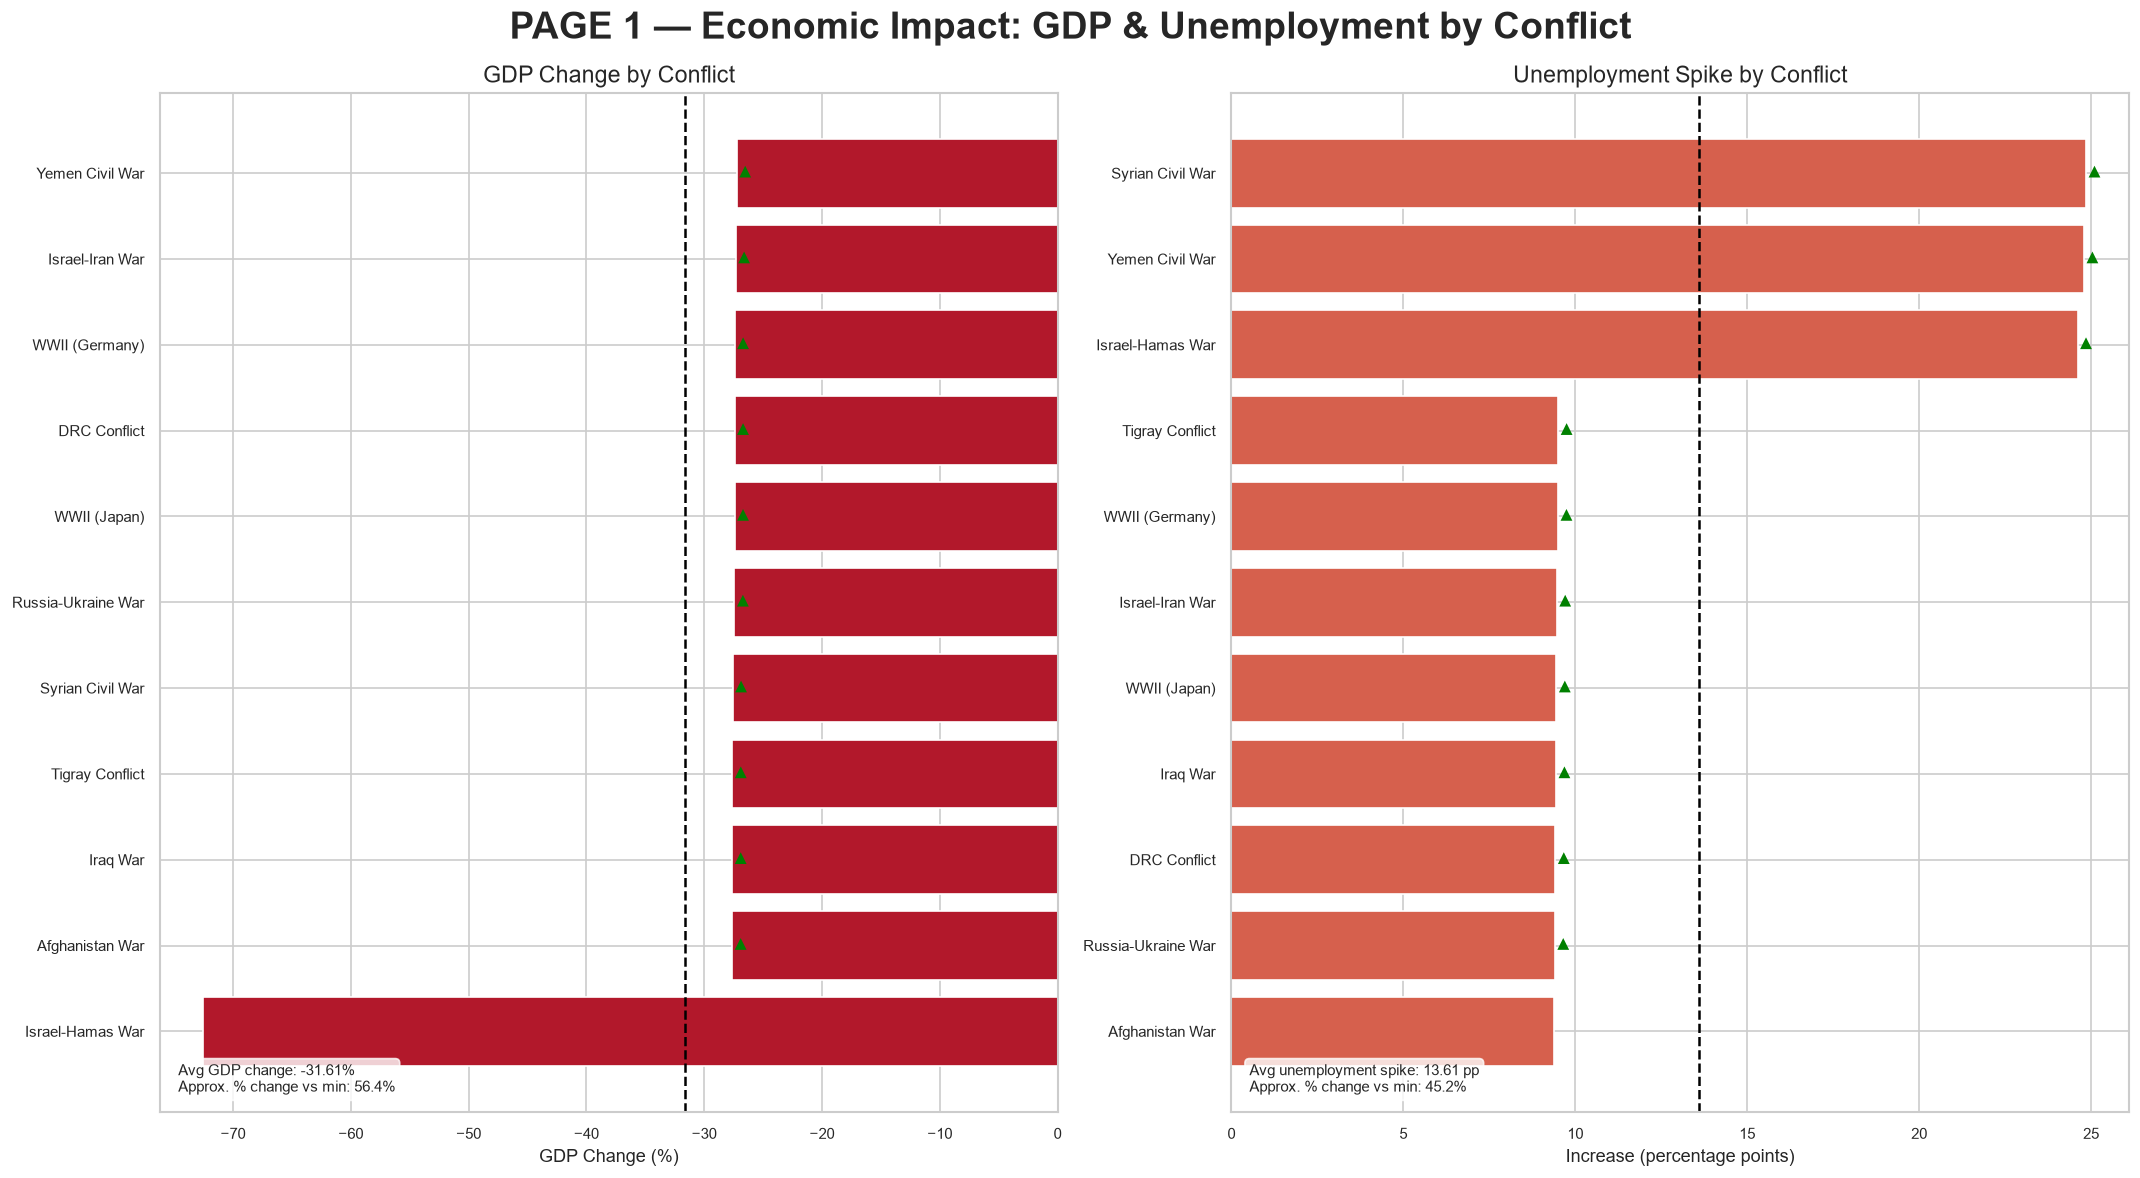

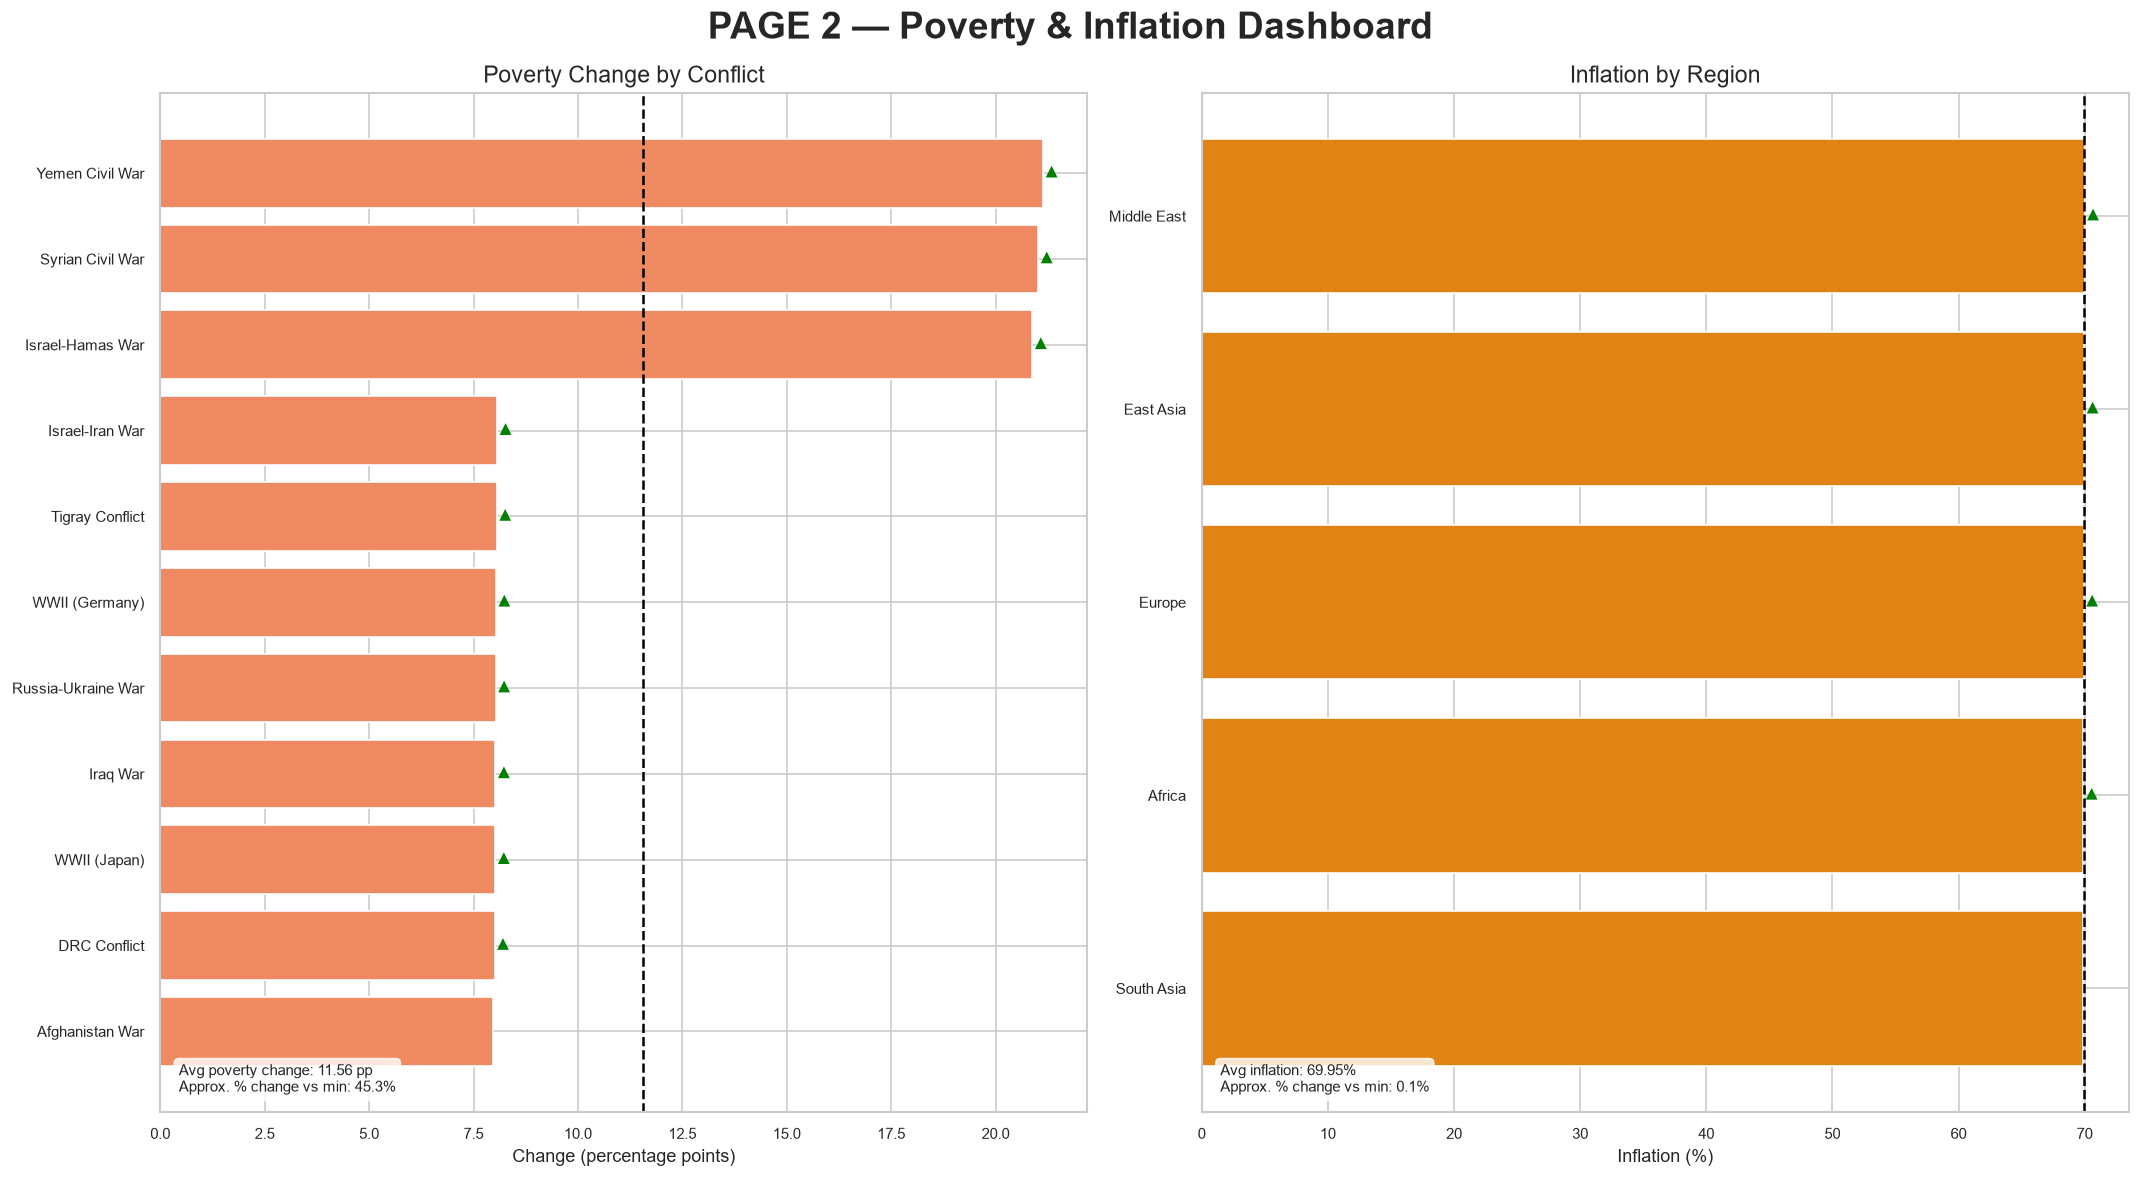

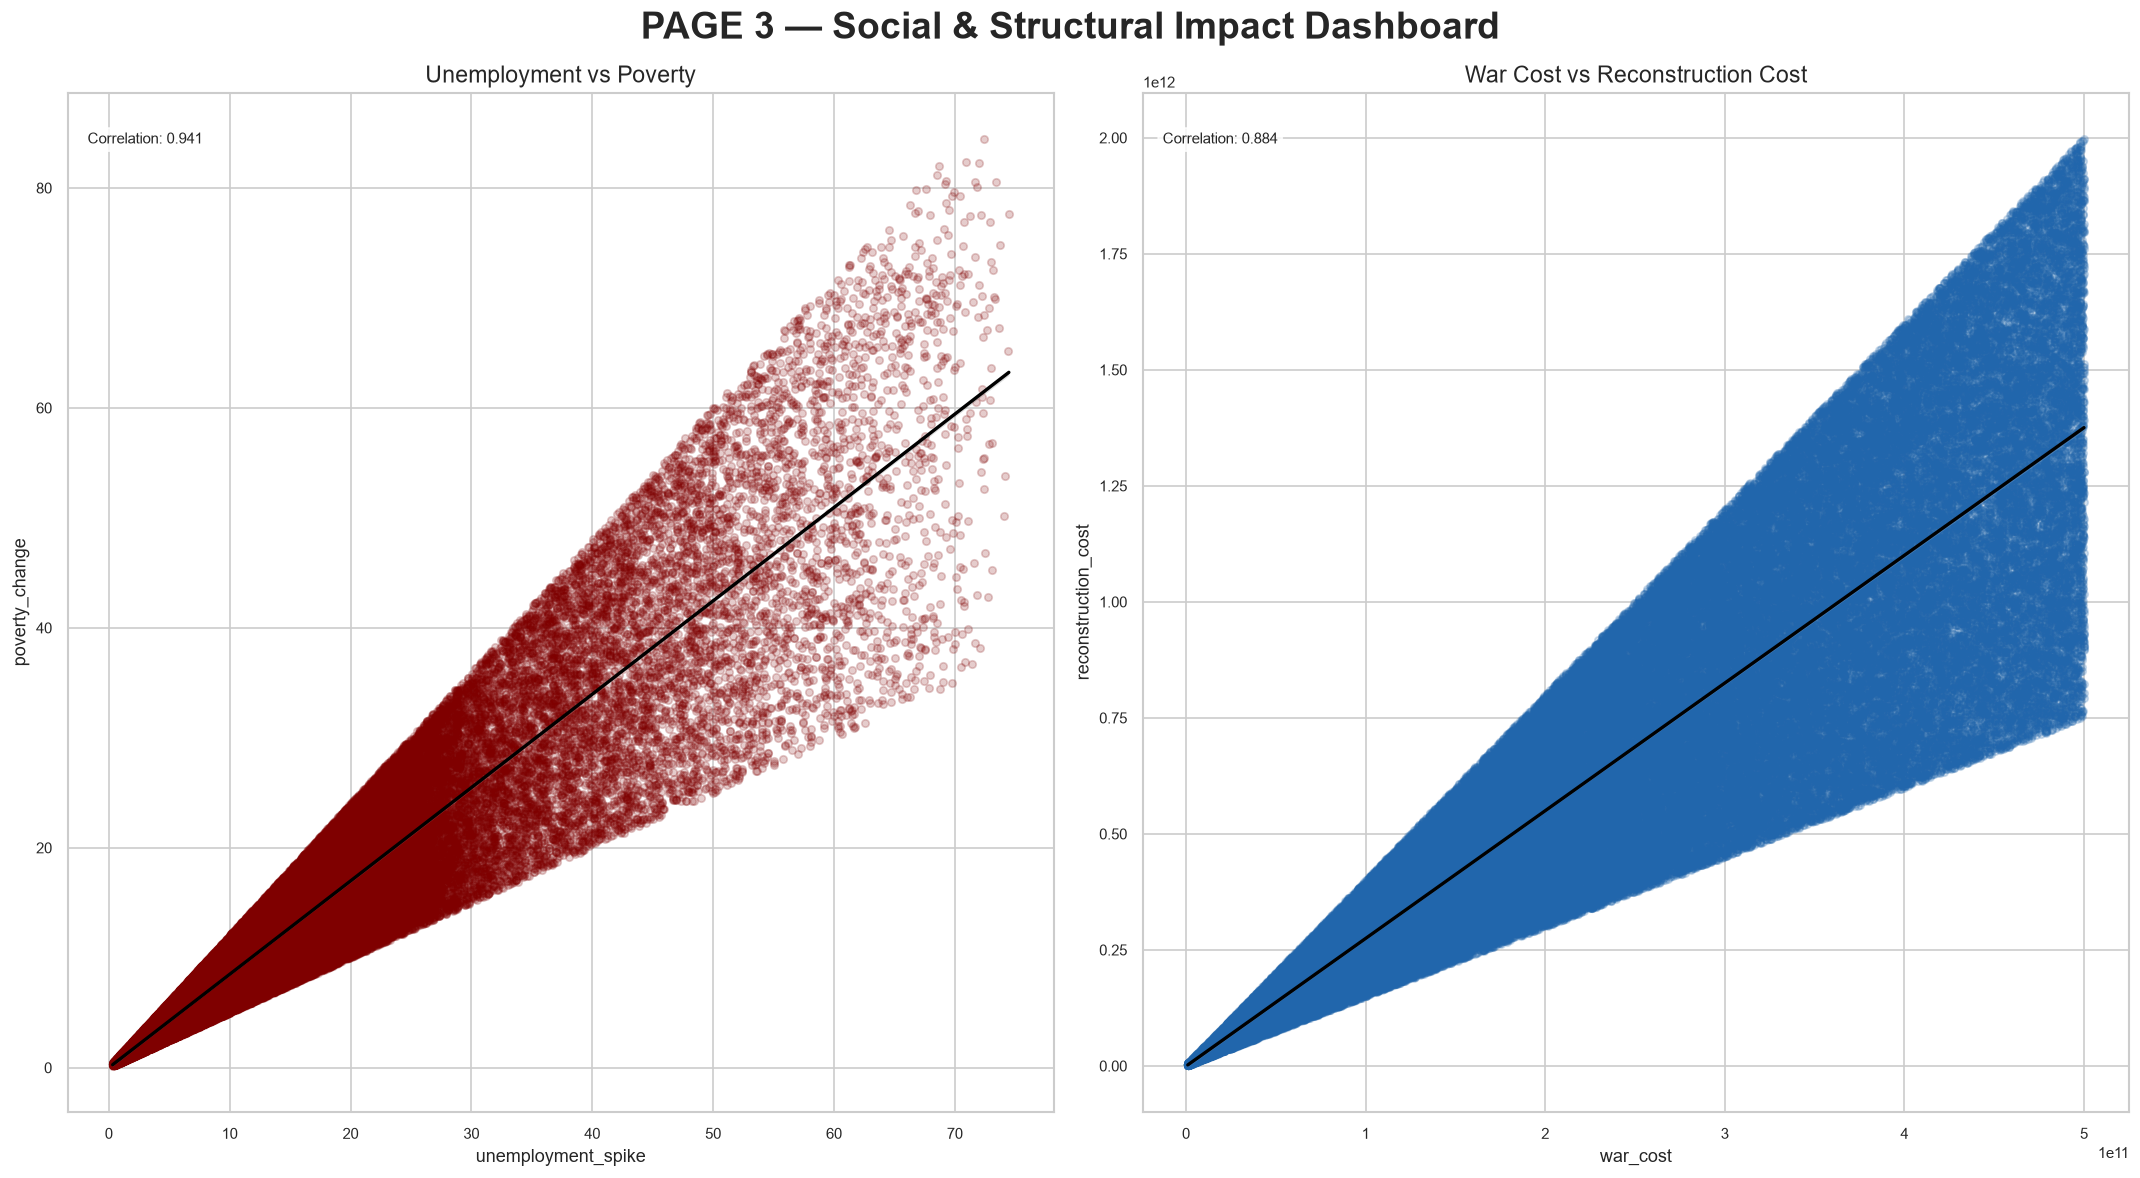

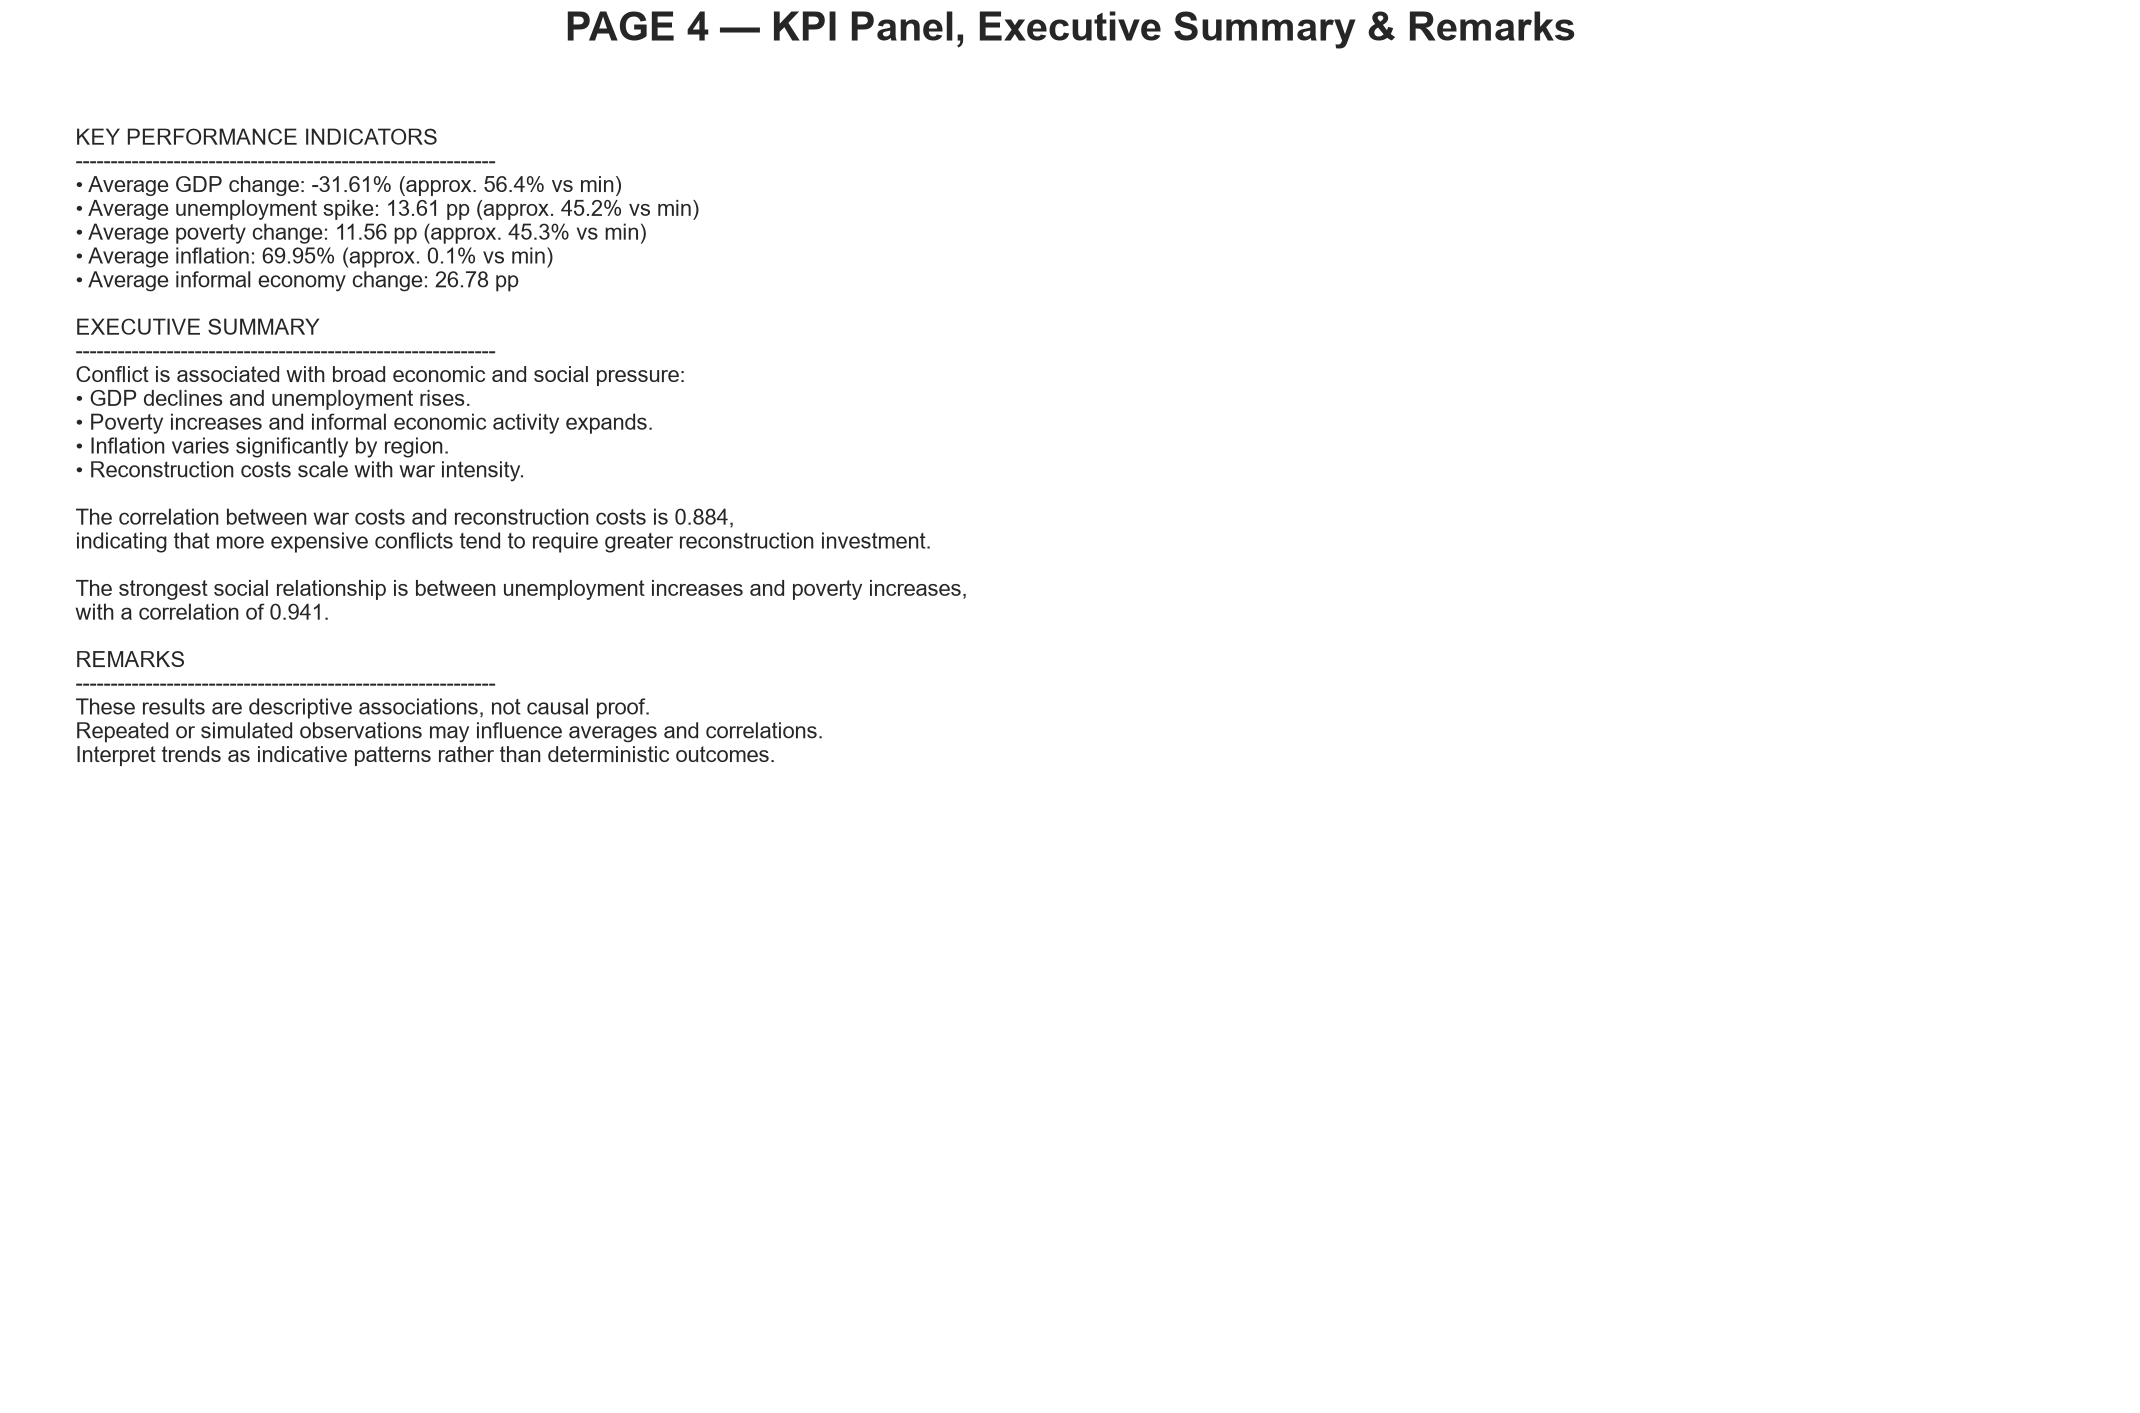

In [1]:
# ============================================================
# FOUR-PAGE DASHBOARD: WAR'S ECONOMIC & SOCIAL IMPACT (STRUCTURED)
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

DATA_PATH = Path("war_economic_impact_dataset.csv")
OUTPUT_DIR = Path("war_impact_figures_four_page")
OUTPUT_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

# ------------------------------------------------------------
# 2. Load and prepare data
# ------------------------------------------------------------

df = pd.read_csv(DATA_PATH)

df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace("%", "pct", regex=False)
      .str.replace(r"[^a-z0-9]+", "_", regex=True)
      .str.strip("_")
)

rename_columns = {
    "conflict_name": "conflict",
    "primary_country": "country",
    "pre_war_unemployment_pct": "pre_unemployment",
    "during_war_unemployment_pct": "during_unemployment",
    "unemployment_spike_percentage_points": "unemployment_spike",
    "pre_war_poverty_rate_pct": "pre_poverty",
    "during_war_poverty_rate_pct": "during_poverty",
    "youth_unemployment_change_pct": "youth_unemployment_change",
    "extreme_poverty_rate_pct": "extreme_poverty",
    "food_insecurity_rate_pct": "food_insecurity",
    "households_fallen_into_poverty_estimate": "households_into_poverty",
    "gdp_change_pct": "gdp_change",
    "inflation_rate_pct": "inflation",
    "currency_devaluation_pct": "currency_devaluation",
    "cost_of_war_usd": "war_cost",
    "estimated_reconstruction_cost_usd": "reconstruction_cost",
    "informal_economy_size_pre_war_pct": "informal_pre",
    "informal_economy_size_during_war_pct": "informal_during",
    "currency_black_market_rate_gap_pct": "black_market_rate_gap",
    "black_market_activity_level": "black_market_level",
    "primary_black_market_goods": "black_market_goods",
    "war_profiteering_documented": "war_profiteering",
    "most_affected_sector": "affected_sector",
}

df.rename(columns={old: new for old, new in rename_columns.items() if old in df.columns}, inplace=True)

text_columns = df.select_dtypes(include=["object", "string", "category"]).columns
for column in text_columns:
    df[column] = (
        df[column].astype("string")
        .str.strip()
        .replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})
        .fillna("Unknown")
    )

numeric_columns = [
    "start_year", "end_year", "pre_unemployment", "during_unemployment",
    "unemployment_spike", "youth_unemployment_change", "pre_poverty",
    "during_poverty", "extreme_poverty", "food_insecurity",
    "households_into_poverty", "gdp_change", "inflation",
    "currency_devaluation", "war_cost", "reconstruction_cost",
    "informal_pre", "informal_during", "black_market_rate_gap"
]

numeric_columns = [col for col in numeric_columns if col in df.columns]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(df[col].median())

# ------------------------------------------------------------
# 3. Feature engineering
# ------------------------------------------------------------

df["poverty_change"] = df["during_poverty"] - df["pre_poverty"]
df["informal_economy_change"] = df["informal_during"] - df["informal_pre"]
df["reconstruction_premium"] = (df["reconstruction_cost"] - df["war_cost"]) / df["war_cost"] * 100

# ------------------------------------------------------------
# 4. Aggregations
# ------------------------------------------------------------

conflict_summary = df.groupby("conflict", as_index=False).agg(
    observations=("conflict", "size"),
    gdp_change=("gdp_change", "mean"),
    unemployment_spike=("unemployment_spike", "mean"),
    poverty_change=("poverty_change", "mean"),
    inflation=("inflation", "mean"),
    informal_economy_change=("informal_economy_change", "mean"),
    war_cost=("war_cost", "mean"),
    reconstruction_cost=("reconstruction_cost", "mean"),
)

region_summary = df.groupby("region", as_index=False).agg(
    gdp_change=("gdp_change", "mean"),
    unemployment_spike=("unemployment_spike", "mean"),
    poverty_change=("poverty_change", "mean"),
    inflation=("inflation", "mean"),
    informal_economy_change=("informal_economy_change", "mean"),
)

# ------------------------------------------------------------
# 5. KPIs
# ------------------------------------------------------------

average_gdp_change = df["gdp_change"].mean()
average_unemployment_spike = df["unemployment_spike"].mean()
average_poverty_change = df["poverty_change"].mean()
average_inflation = df["inflation"].mean()
average_informal_change = df["informal_economy_change"].mean()

cost_correlation = df[["war_cost", "reconstruction_cost"]].corr().iloc[0, 1]
poverty_unemployment_correlation = df[["poverty_change", "unemployment_spike"]].corr().iloc[0, 1]

# Helper: percentage change vs min
def pct_increase(series, avg):
    base = series.min()
    if base == 0:
        return np.nan
    return (avg - base) / abs(base) * 100

gdp_pct_inc = pct_increase(conflict_summary["gdp_change"], average_gdp_change)
unemp_pct_inc = pct_increase(conflict_summary["unemployment_spike"], average_unemployment_spike)
poverty_pct_inc = pct_increase(conflict_summary["poverty_change"], average_poverty_change)
infl_pct_inc = pct_increase(region_summary["inflation"], average_inflation)

# ============================================================
# DASHBOARD 1 (PAGE 1) — GDP & UNEMPLOYMENT BY CONFLICT
# ============================================================

fig1, axes = plt.subplots(1, 2, figsize=(18, 10))
fig1.suptitle("PAGE 1 — Economic Impact: GDP & Unemployment by Conflict", fontsize=22, fontweight="bold")

# GDP Change by Conflict
plot_gdp = conflict_summary.sort_values("gdp_change")
colors_gdp = ["#b2182b" if v < 0 else "#2166ac" for v in plot_gdp["gdp_change"]]

axes[0].barh(plot_gdp["conflict"], plot_gdp["gdp_change"], color=colors_gdp)
axes[0].set_title("GDP Change by Conflict")
axes[0].set_xlabel("GDP Change (%)")

# Trend markers (slope-based arrows)
gdp_vals = plot_gdp["gdp_change"].values
for i in range(1, len(gdp_vals)):
    slope = gdp_vals[i] - gdp_vals[i - 1]
    arrow = "▲" if slope > 0 else "▼"
    color = "green" if slope > 0 else "red"
    axes[0].text(gdp_vals[i], i, arrow, fontsize=10, color=color, va="center")

# Average line
axes[0].axvline(average_gdp_change, color="black", linestyle="--", linewidth=1.5)

# Summary text for GDP
axes[0].text(
    0.02, 0.02,
    f"Avg GDP change: {average_gdp_change:.2f}%\n"
    f"Approx. % change vs min: {gdp_pct_inc:.1f}%",
    transform=axes[0].transAxes,
    fontsize=9,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

# Unemployment Spike by Conflict
plot_unemp = conflict_summary.sort_values("unemployment_spike")
axes[1].barh(plot_unemp["conflict"], plot_unemp["unemployment_spike"], color="#d6604d")
axes[1].set_title("Unemployment Spike by Conflict")
axes[1].set_xlabel("Increase (percentage points)")

unemp_vals = plot_unemp["unemployment_spike"].values
for i in range(1, len(unemp_vals)):
    slope = unemp_vals[i] - unemp_vals[i - 1]
    arrow = "▲" if slope > 0 else "▼"
    color = "green" if slope > 0 else "red"
    axes[1].text(unemp_vals[i], i, arrow, fontsize=10, color=color, va="center")

axes[1].axvline(average_unemployment_spike, color="black", linestyle="--", linewidth=1.5)

axes[1].text(
    0.02, 0.02,
    f"Avg unemployment spike: {average_unemployment_spike:.2f} pp\n"
    f"Approx. % change vs min: {unemp_pct_inc:.1f}%",
    transform=axes[1].transAxes,
    fontsize=9,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.tight_layout()
fig1.savefig(OUTPUT_DIR / "page1_gdp_unemployment_dashboard.png")

# ============================================================
# DASHBOARD 2 (PAGE 2) — POVERTY & INFLATION
# ============================================================

fig2, axes = plt.subplots(1, 2, figsize=(18, 10))
fig2.suptitle("PAGE 2 — Poverty & Inflation Dashboard", fontsize=22, fontweight="bold")

# Poverty Change by Conflict
plot_pov = conflict_summary.sort_values("poverty_change")
colors_pov = ["#ef8a62" if v > 0 else "#2166ac" for v in plot_pov["poverty_change"]]

axes[0].barh(plot_pov["conflict"], plot_pov["poverty_change"], color=colors_pov)
axes[0].set_title("Poverty Change by Conflict")
axes[0].set_xlabel("Change (percentage points)")

pov_vals = plot_pov["poverty_change"].values
for i in range(1, len(pov_vals)):
    slope = pov_vals[i] - pov_vals[i - 1]
    arrow = "▲" if slope > 0 else "▼"
    color = "green" if slope > 0 else "red"
    axes[0].text(pov_vals[i], i, arrow, fontsize=10, color=color, va="center")

axes[0].axvline(average_poverty_change, color="black", linestyle="--", linewidth=1.5)

axes[0].text(
    0.02, 0.02,
    f"Avg poverty change: {average_poverty_change:.2f} pp\n"
    f"Approx. % change vs min: {poverty_pct_inc:.1f}%",
    transform=axes[0].transAxes,
    fontsize=9,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

# Inflation by Region
plot_infl = region_summary.sort_values("inflation")
axes[1].barh(plot_infl["region"], plot_infl["inflation"], color="#e08214")
axes[1].set_title("Inflation by Region")
axes[1].set_xlabel("Inflation (%)")

infl_vals = plot_infl["inflation"].values
for i in range(1, len(infl_vals)):
    slope = infl_vals[i] - infl_vals[i - 1]
    arrow = "▲" if slope > 0 else "▼"
    color = "green" if slope > 0 else "red"
    axes[1].text(infl_vals[i], i, arrow, fontsize=10, color=color, va="center")

axes[1].axvline(average_inflation, color="black", linestyle="--", linewidth=1.5)

axes[1].text(
    0.02, 0.02,
    f"Avg inflation: {average_inflation:.2f}%\n"
    f"Approx. % change vs min: {infl_pct_inc:.1f}%",
    transform=axes[1].transAxes,
    fontsize=9,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.tight_layout()
fig2.savefig(OUTPUT_DIR / "page2_poverty_inflation_dashboard.png")

# ============================================================
# DASHBOARD 3 (PAGE 3) — SOCIAL & STRUCTURAL IMPACT
# ============================================================

fig3, axes = plt.subplots(1, 2, figsize=(18, 10))
fig3.suptitle("PAGE 3 — Social & Structural Impact Dashboard", fontsize=22, fontweight="bold")

# Unemployment vs Poverty (scatter + trend)
sns.regplot(
    data=df,
    x="unemployment_spike",
    y="poverty_change",
    scatter_kws={"alpha": 0.2, "s": 20, "color": "#7f0000"},
    line_kws={"color": "black", "linewidth": 2},
    ax=axes[0]
)
axes[0].set_title("Unemployment vs Poverty")

axes[0].text(
    0.02, 0.95,
    f"Correlation: {poverty_unemployment_correlation:.3f}",
    transform=axes[0].transAxes,
    fontsize=9,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

# War Cost vs Reconstruction Cost
sns.regplot(
    data=df,
    x="war_cost",
    y="reconstruction_cost",
    scatter_kws={"alpha": 0.2, "s": 20, "color": "#2166ac"},
    line_kws={"color": "black", "linewidth": 2},
    ax=axes[1]
)
axes[1].set_title("War Cost vs Reconstruction Cost")

axes[1].text(
    0.02, 0.95,
    f"Correlation: {cost_correlation:.3f}",
    transform=axes[1].transAxes,
    fontsize=9,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.tight_layout()
fig3.savefig(OUTPUT_DIR / "page3_social_structural_dashboard.png")

# ============================================================
# DASHBOARD 4 (PAGE 4) — KPI, EXECUTIVE SUMMARY & REMARKS
# ============================================================

fig4, ax = plt.subplots(figsize=(18, 12))
fig4.suptitle("PAGE 4 — KPI Panel, Executive Summary & Remarks", fontsize=24, fontweight="bold")

kpi_text = f"""
KEY PERFORMANCE INDICATORS
------------------------------------------------------------
• Average GDP change: {average_gdp_change:.2f}% (approx. {gdp_pct_inc:.1f}% vs min)
• Average unemployment spike: {average_unemployment_spike:.2f} pp (approx. {unemp_pct_inc:.1f}% vs min)
• Average poverty change: {average_poverty_change:.2f} pp (approx. {poverty_pct_inc:.1f}% vs min)
• Average inflation: {average_inflation:.2f}% (approx. {infl_pct_inc:.1f}% vs min)
• Average informal economy change: {average_informal_change:.2f} pp

EXECUTIVE SUMMARY
------------------------------------------------------------
Conflict is associated with broad economic and social pressure:
• GDP declines and unemployment rises.
• Poverty increases and informal economic activity expands.
• Inflation varies significantly by region.
• Reconstruction costs scale with war intensity.

The correlation between war costs and reconstruction costs is {cost_correlation:.3f},
indicating that more expensive conflicts tend to require greater reconstruction investment.

The strongest social relationship is between unemployment increases and poverty increases,
with a correlation of {poverty_unemployment_correlation:.3f}.

REMARKS
------------------------------------------------------------
These results are descriptive associations, not causal proof.
Repeated or simulated observations may influence averages and correlations.
Interpret trends as indicative patterns rather than deterministic outcomes.
"""

ax.text(0.03, 0.97, kpi_text, fontsize=13, va="top")
ax.axis("off")

plt.tight_layout()
fig4.savefig(OUTPUT_DIR / "page4_kpi_summary_remarks.png")

print("Four-page structured dashboard generated successfully!")
print(f"Saved in: {OUTPUT_DIR.resolve()}")
